# 03 — Baseline MLP Neuronska Mreža (PyTorch)
**Cilj:** Izgraditi i istrenirati osnovnu MLP mrežu (Multi-Layer Perceptron) kao baseline model.
Poredimo tri pristupa za tretman nebalansiranosti: `class_weight`, `SMOTE`, `SMOTE+Under`.

> **Framework:** Ovaj notebook koristi **PyTorch** umesto TensorFlow/Keras.

---

## 0. Imports i konfiguracija

Uvozimo sve potrebne biblioteke:
- **`torch` / `torch.nn`** — PyTorch framework za izgradnju i trening neuronskih mreža
- **`torch.utils.data`** — klase za efikasno upravljanje datasetima i mini-batch učitavanjem
- **`sklearn.metrics`** — metrike evaluacije (ROC-AUC, PR-AUC, F1, itd.)
- **`numpy` / `pandas` / `matplotlib` / `seaborn`** — standardne biblioteke za numeriku i vizualizaciju

**`RANDOM_SEED = 42`** — fiksiramo seed za reproduktibilnost rezultata na svim nivoima (NumPy, PyTorch, CUDA).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, f1_score
)

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# Koristimo GPU ako je dostupan, inače CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROC    = '../data/processed/'
MODELS  = '../models/'
RESULTS = '../results/'
os.makedirs(MODELS, exist_ok=True)

print(f'PyTorch verzija: {torch.__version__}')
print(f'Uređaj: {DEVICE}')

PyTorch verzija: 2.12.0+cpu
Uređaj: cpu


## 1. Učitavanje procesiranih podataka

Učitavamo `.npy` fajlove sačuvane u prethodnom notebooku (preprocessing):
- `X_train / X_val / X_test` — feature matrice (već skalirane)
- `y_train / y_val / y_test` — binarne labele (0 = legitimna, 1 = fraud)
- `X_train_smote` / `X_train_comb` — oversampled verzije za SMOTE eksperimente
- `class_weights.json` — unapred izračunati težinski faktori klasa za tretman nebalanse

Podatke konvertujemo u **PyTorch Tensor** objekte i prebacujemo na odabrani `DEVICE`.

In [2]:
X_train       = np.load(f'{PROC}X_train.npy')
X_val         = np.load(f'{PROC}X_val.npy')
X_test        = np.load(f'{PROC}X_test.npy')
y_train       = np.load(f'{PROC}y_train.npy')
y_val         = np.load(f'{PROC}y_val.npy')
y_test        = np.load(f'{PROC}y_test.npy')
X_train_smote = np.load(f'{PROC}X_train_smote.npy')
y_train_smote = np.load(f'{PROC}y_train_smote.npy')
X_train_comb  = np.load(f'{PROC}X_train_combined.npy')
y_train_comb  = np.load(f'{PROC}y_train_combined.npy')

with open(f'{PROC}class_weights.json') as f:
    cw = json.load(f)
# Težina za pozitivnu klasu (fraud) u BCEWithLogitsLoss
pos_weight_value = cw['1'] / cw['0']
POS_WEIGHT = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

INPUT_DIM = X_train.shape[1]


def make_loader(X, y, batch_size=256, shuffle=True):
    """Kreira PyTorch DataLoader iz NumPy nizova."""
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N,) -> (N,1)
    dataset = TensorDataset(X_t, y_t)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)


train_loader       = make_loader(X_train, y_train)
train_smote_loader = make_loader(X_train_smote, y_train_smote)
train_comb_loader  = make_loader(X_train_comb, y_train_comb)
val_loader         = make_loader(X_val, y_val, shuffle=False)
test_loader        = make_loader(X_test, y_test, shuffle=False)

# Fiksni tenzori za evaluaciju (bez batcheva)
X_val_t  = torch.tensor(X_val,  dtype=torch.float32).to(DEVICE)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

print(f'Input dim: {INPUT_DIM}')
print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'pos_weight (fraud/legit ratio): {pos_weight_value:.2f}')

Input dim: 31
Train: (198608, 31), Val: (42559, 31), Test: (42559, 31)
pos_weight (fraud/legit ratio): 599.02


## 2. Helper funkcije

Definišemo pomoćne funkcije koje će se koristiti tokom celog notebooka:

- **`plot_history`** — crta krive gubitka i PR-AUC metrike kroz epohe (train vs validation)
- **`evaluate_model`** — sveobuhvatna evaluacija: confusion matrix, ROC kriva, PR kriva i izveštaj po klasama
- **`find_best_threshold`** — traži optimalni prag klasifikacije koji maksimizuje F1 na validation setu

**Napomena o PyTorch evaluaciji:** Za razliku od Kerasa, PyTorch nema `.predict()` metodu. Umesto toga, pozivamo `model.eval()` pre predikcije i koristimo `torch.no_grad()` kontekst da onemogućimo računanje gradijenata (brže, manje memorije). Izlaz mreže su logiti — primenjujemo `torch.sigmoid()` da dobijemo verovatnoće.

In [3]:
def plot_history(train_losses, val_losses, train_aucs, val_aucs, title='Training History', save_path=None):
    """Prikazuje loss i PR-AUC kroz epohe."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(train_losses, label='Train Loss')
    axes[0].plot(val_losses,   label='Val Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].set_xlabel('Epoha')
    axes[0].legend()

    axes[1].plot(train_aucs, label='Train PR-AUC')
    axes[1].plot(val_aucs,   label='Val PR-AUC')
    axes[1].set_title(f'{title} — PR-AUC')
    axes[1].set_xlabel('Epoha')
    axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def predict_proba(model, X_tensor):
    """Inference u eval modu — vraća NumPy niz verovatnoća."""
    model.eval()
    with torch.no_grad():
        logits = model(X_tensor)
        probs  = torch.sigmoid(logits).cpu().numpy().ravel()
    return probs


def evaluate_model(model, X_tensor, y_test, threshold=0.5, title='Model', save_path=None):
    """Kompletna evaluacija: CM, ROC, PR kriva, klasifikacioni izveštaj."""
    y_prob = predict_proba(model, X_tensor)
    y_pred = (y_prob >= threshold).astype(int)

    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)
    f1      = f1_score(y_test, y_pred)

    print(f'\n=== {title} ===')
    print(f'ROC-AUC:  {roc_auc:.4f}')
    print(f'PR-AUC:   {pr_auc:.4f}  ← glavna metrika za imbalanced')
    print(f'F1-Score: {f1:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Legitimna', 'Fraud']))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('Stvarno')
    axes[0].set_xlabel('Predviđeno')

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title('ROC Kriva')
    axes[1].legend()

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[2].plot(rec, prec, color='steelblue', lw=2, label=f'PR-AUC = {pr_auc:.4f}')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title('Precision-Recall Kriva')
    axes[2].legend()

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    return {'title': title, 'roc_auc': roc_auc, 'pr_auc': pr_auc, 'f1': f1}


def find_best_threshold(model, X_tensor, y_val):
    """Pronalazi optimalni threshold po F1 na validation setu."""
    y_prob = predict_proba(model, X_tensor)
    thresholds = np.linspace(0.1, 0.9, 81)
    f1s = [f1_score(y_val, (y_prob >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(f1s)]
    print(f'Optimalni threshold (F1): {best_t:.2f} → F1 = {max(f1s):.4f}')
    return best_t


print('✅ Helper funkcije definisane')

✅ Helper funkcije definisane


## 3. Definicija Baseline MLP arhitekture

U PyTorchu mreže se definišu kao klase koje nasleđuju `nn.Module`. Svaka klasa mora imati:
- **`__init__`** — definiše slojeve mreže
- **`forward`** — definiše kako podaci prolaze kroz mrežu (forward pass)

**Arhitektura:**
```
Input(31) → Dense(64, ReLU) → Dropout(0.3) → Dense(32, ReLU) → Dropout(0.3) → Dense(16, ReLU) → Dense(1)
```

**Napomene o implementaciji:**
- Koristimo `nn.Sequential` blokove za urednu definiciju slojeva
- Izlazni sloj **nema sigmoid aktivaciju** — PyTorch preporučuje da se sigmoid (ili softmax) primenjuje unutar loss funkcije (`BCEWithLogitsLoss`) zbog numeričke stabilnosti
- `nn.ModuleList` je potreban da bi PyTorch pratio parametre dinamički kreiranih slojeva

In [4]:
class BaselineMLP(nn.Module):
    """
    Baseline MLP za detekciju prevara.
    Arhitektura: Input -> [Dense(units, ReLU) -> Dropout] x N -> Dense(1)
    Izlaz su LOGITI (bez sigmoid) — sigmoid se primenjuje u loss funkciji.
    """
    def __init__(self, input_dim, hidden_units=(64, 32, 16), dropout_rate=0.3):
        super().__init__()
        layers_list = []
        in_features = input_dim
        for units in hidden_units:
            layers_list.append(
                nn.Sequential(
                    nn.Linear(in_features, units),
                    nn.ReLU(),
                    nn.Dropout(p=dropout_rate)
                )
            )
            in_features = units
        self.hidden = nn.ModuleList(layers_list)
        self.output = nn.Linear(in_features, 1)  # bez aktivacije — logiti
        self._init_weights()

    def _init_weights(self):
        """He (Kaiming) inicijalizacija težina za ReLU aktivacije."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
                nn.init.zeros_(module.bias)

    def forward(self, x):
        for layer in self.hidden:
            x = layer(x)
        return self.output(x)


# Pregled arhitekture
demo_model = BaselineMLP(INPUT_DIM)
print(demo_model)
total_params = sum(p.numel() for p in demo_model.parameters() if p.requires_grad)
print(f'\nUkupno trenabilnih parametara: {total_params:,}')

BaselineMLP(
  (hidden): ModuleList(
    (0): Sequential(
      (0): Linear(in_features=31, out_features=64, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=64, out_features=32, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
    (2): Sequential(
      (0): Linear(in_features=32, out_features=16, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.3, inplace=False)
    )
  )
  (output): Linear(in_features=16, out_features=1, bias=True)
)

Ukupno trenabilnih parametara: 4,673


## 4. Training Loop

U PyTorchu nema ugrađene `.fit()` metode kao u Kerasu — moramo ručno pisati training loop. Ovo nam daje punu kontrolu, ali zahteva više koda.

**Svaka epoha se sastoji od:**

**Faza treniranja:**
1. `model.train()` — aktivira Dropout i BatchNorm u trening modu
2. Iteriramo kroz mini-batcheve iz DataLoader-a
3. `optimizer.zero_grad()` — resetujemo gradijente iz prethodne iteracije
4. `loss.backward()` — backpropagation (računamo gradijente)
5. `optimizer.step()` — ažuriramo težine

**Faza validacije:**
1. `model.eval()` + `torch.no_grad()` — isključujemo Dropout, ne računamo gradijente
2. Računamo val loss i PR-AUC na celom validation setu

**Early Stopping** — pratimo `val_pr_auc` i čuvamo beste težine (`state_dict`) kada se poboljša. Ako se nije poboljšalo `patience` epoha zaredom, zaustavljamo trening i vraćamo beste težine.

In [7]:
def train_model(model, train_loader, X_val_t, y_val,
                pos_weight=None, epochs=100, lr=1e-3,
                patience=10, model_name='model', l2=1e-4):
    """
    Kompletna training petlja sa:
    - BCEWithLogitsLoss (pos_weight za class imbalance)
    - Adam optimizer sa L2 regularizacijom (weight_decay)
    - ReduceLROnPlateau scheduling
    - Early stopping praćen na val PR-AUC
    - Čuvanje najboljeg modela na disk
    """
    model = model.to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=l2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=5,
        min_lr=1e-6
    )

    best_val_auc  = -1.0
    best_weights  = None
    patience_cnt  = 0
    train_losses, val_losses = [], []
    train_aucs,   val_aucs   = [], []

    for epoch in range(1, epochs + 1):
        # ---------- TRENING ----------
        model.train()
        running_loss = 0.0
        all_probs, all_labels = [], []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy().ravel())

        train_loss = running_loss / len(train_loader.dataset)
        train_auc  = average_precision_score(all_labels, all_probs)

        # ---------- VALIDACIJA ----------
        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t)
            val_loss   = criterion(
                val_logits,
                torch.tensor(y_val, dtype=torch.float32).unsqueeze(1).to(DEVICE)
            ).item()
            val_probs  = torch.sigmoid(val_logits).cpu().numpy().ravel()
        val_auc = average_precision_score(y_val, val_probs)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_aucs.append(train_auc)
        val_aucs.append(val_auc)

        scheduler.step(val_auc)

        if epoch % 10 == 0:
            print(f'Epoha {epoch:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} '
                  f'| Train PR-AUC: {train_auc:.4f} | Val PR-AUC: {val_auc:.4f}')

        # Early stopping
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            # Čuvamo kopiju težina u memoriji
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_weights, f'{MODELS}{model_name}.pt')
            patience_cnt = 0
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'\nEarly stopping na epohi {epoch} | Beste Val PR-AUC: {best_val_auc:.4f}')
                break

    # Vraćamo beste težine
    model.load_state_dict(best_weights)
    return model, train_losses, val_losses, train_aucs, val_aucs


print('✅ Training funkcija definisana')

✅ Training funkcija definisana


## 5. Eksperiment A — Class Weight (bez resamplinga)

**Strategija:** Treniramo na originalnim (nebalansiranim) podacima, ali korigujemo loss funkciju.

`BCEWithLogitsLoss(pos_weight=w)` množi gubitak za pozitivne uzorke (fraud) sa faktorom `w`, čime se mreža više "kažnjava" za propuštene prevare. Ovo je ekvivalent `class_weight` parametra u Kerasu.

**Prednost:** Nema generisanja sintetičkih podataka — direktno radimo sa originalnom distribucijom.  
**Mana:** Mreža može biti konzervativna u predikcijama.

Treniram: MLP + class_weight pristup
pos_weight (fraud): 599.02x
Epoha  10 | Train Loss: 0.2802 | Val Loss: 0.5073 | Train PR-AUC: 0.6982 | Val PR-AUC: 0.7183
Epoha  20 | Train Loss: 0.1366 | Val Loss: 0.9725 | Train PR-AUC: 0.7208 | Val PR-AUC: 0.7244
Epoha  30 | Train Loss: 0.1077 | Val Loss: 1.3355 | Train PR-AUC: 0.7349 | Val PR-AUC: 0.7150

Early stopping na epohi 32 | Beste Val PR-AUC: 0.7356


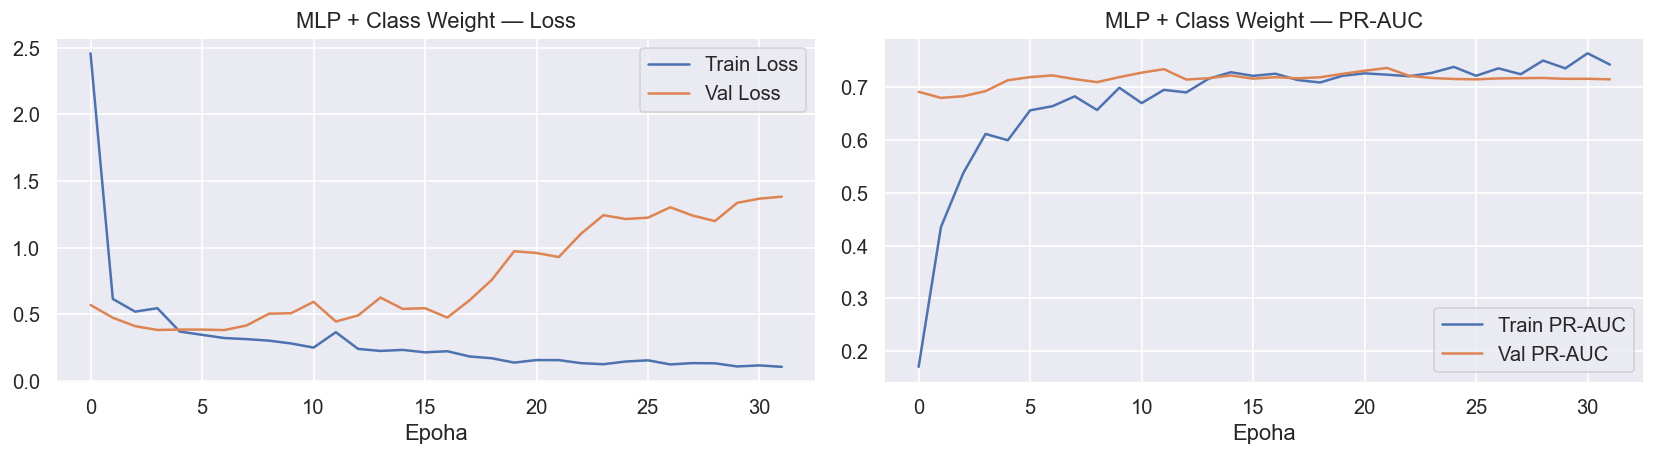

In [8]:
print('Treniram: MLP + class_weight pristup')
print(f'pos_weight (fraud): {pos_weight_value:.2f}x')

model_cw = BaselineMLP(INPUT_DIM)
model_cw, tl_cw, vl_cw, ta_cw, va_cw = train_model(
    model_cw, train_loader, X_val_t, y_val,
    pos_weight=POS_WEIGHT, epochs=100, lr=1e-3,
    patience=10, model_name='mlp_classweight'
)

plot_history(tl_cw, vl_cw, ta_cw, va_cw,
             'MLP + Class Weight', f'{RESULTS}03_mlp_cw_history.png')

## 6. Eksperiment B — SMOTE resampling

**Strategija:** Treniramo na presamplovanim podacima generisanim SMOTE algoritmom (Synthetic Minority Over-sampling Technique). SMOTE kreira sintetičke fraud uzorke interpolacijom između postojećih fraud uzoraka u feature prostoru.

Pošto je klasa ubalansirana samim datasetom, **ne koristimo** `pos_weight` — gubitak tretiramo podjednako za obe klase.

Treniram: MLP + SMOTE
Epoha  10 | Train Loss: 0.0060 | Val Loss: 0.0106 | Train PR-AUC: 0.9978 | Val PR-AUC: 0.7956
Epoha  20 | Train Loss: 0.0035 | Val Loss: 0.0103 | Train PR-AUC: 0.9990 | Val PR-AUC: 0.7948
Epoha  30 | Train Loss: 0.0025 | Val Loss: 0.0103 | Train PR-AUC: 0.9993 | Val PR-AUC: 0.8092

Early stopping na epohi 32 | Beste Val PR-AUC: 0.8192


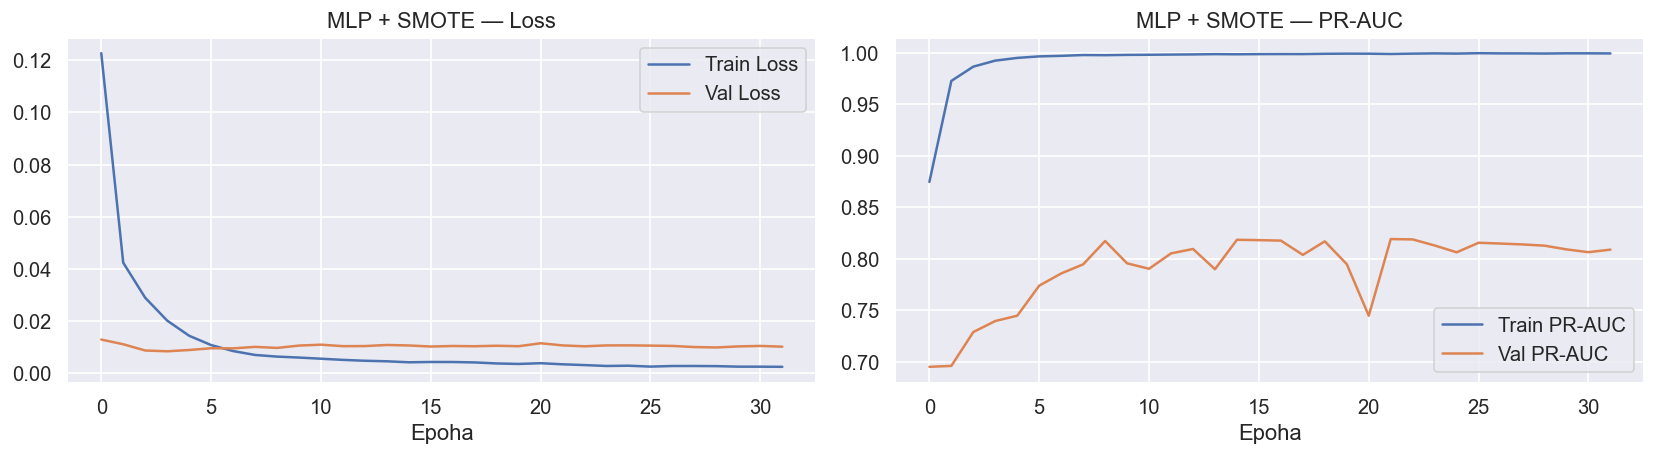

In [9]:
print('Treniram: MLP + SMOTE')

model_smote = BaselineMLP(INPUT_DIM)
model_smote, tl_sm, vl_sm, ta_sm, va_sm = train_model(
    model_smote, train_smote_loader, X_val_t, y_val,
    pos_weight=None, epochs=100, lr=1e-3,
    patience=10, model_name='mlp_smote'
)

plot_history(tl_sm, vl_sm, ta_sm, va_sm,
             'MLP + SMOTE', f'{RESULTS}03_mlp_smote_history.png')

## 7. Eksperiment C — SMOTE + Undersampling

**Strategija:** Kombinovani pristup — SMOTE povećava broj fraud uzoraka, a RandomUnderSampler smanjuje broj legitimnih transakcija. Rezultat je umereniji odnos klasa (npr. 1:5 umesto 1:577), što je kompromis između presamplinga i undersamplinga.

**Prednost:** Manji trening set → brži trening; bolji balans klasa.  
**Mana:** Gubimo deo originalnih podataka (undersampling).

In [ ]:
print('Treniram: MLP + SMOTE + Undersampling')

model_comb = BaselineMLP(INPUT_DIM)
model_comb, tl_cb, vl_cb, ta_cb, va_cb = train_model(
    model_comb, train_comb_loader, X_val_t, y_val,
    pos_weight=None, epochs=100, lr=1e-3,
    patience=10, model_name='mlp_combined'
)

plot_history(tl_cb, vl_cb, ta_cb, va_cb,
             'MLP + SMOTE+Under', f'{RESULTS}03_mlp_comb_history.png')

## 8. Evaluacija i poređenje na Test setu

Za svaki model:
1. **Nalazimo optimalni threshold** na validation setu (ne na test setu! — izbegavamo data leakage)
2. **Evaluiramo na test setu** koristeći taj threshold
3. **Vizualizujemo** confusion matrix, ROC i PR krive

**Zašto PR-AUC a ne ROC-AUC?** Kod ekstremno nebalansiranih datasetova (0.17% fraud), ROC-AUC može biti visok čak i za loš model, jer ima mnogo true negatives koji "lako" podižu metriku. PR-AUC direktno meri koliko dobro model detektuje prevare, bez uticaja majority klase.

In [ ]:
results = []

for model, name, save in [
    (model_cw,    'MLP + Class Weight',  f'{RESULTS}03_eval_cw.png'),
    (model_smote, 'MLP + SMOTE',         f'{RESULTS}03_eval_smote.png'),
    (model_comb,  'MLP + SMOTE+Under',   f'{RESULTS}03_eval_comb.png'),
]:
    best_t = find_best_threshold(model, X_val_t, y_val)
    res    = evaluate_model(model, X_test_t, y_test, threshold=best_t,
                            title=name, save_path=save)
    res['threshold'] = best_t
    results.append(res)

In [ ]:
# Sumarno poređenje
results_df = pd.DataFrame(results).set_index('title')
print('\n=== SUMARNO POREĐENJE BASELINE MODELA ===')
display(results_df[['roc_auc', 'pr_auc', 'f1', 'threshold']]
        .style.highlight_max(color='#90EE90', subset=['roc_auc', 'pr_auc', 'f1']))

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
w = 0.25
ax.bar(x - w, results_df['roc_auc'], w, label='ROC-AUC', color='steelblue')
ax.bar(x,     results_df['pr_auc'],  w, label='PR-AUC',  color='coral')
ax.bar(x + w, results_df['f1'],      w, label='F1',       color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=10)
ax.set_ylim(0.7, 1.0)
ax.legend()
ax.set_title('Poređenje Baseline MLP Modela', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULTS}03_comparison.png', bbox_inches='tight')
plt.show()

results_df.to_csv(f'{RESULTS}03_baseline_results.csv')
print('\n→ Sledeći notebook: 04_advanced_nn.ipynb')